In [37]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [38]:
filename = 'data\ADNI_Tadpole_data_tutorial.xlsx'
data_df = pd.read_excel(filename)
data_df.head()

y_target = data_df['Amyloid status']
x_data = data_df.drop(['PTID','SUVR','Amyloid status'], axis = 1)

In [39]:
data_df.head()


,PTID,SUVR,Amyloid status,AGE,GENDER,EDUCATION,Diagnosis,ApoE4,CDRSB,ADAS11,...,Supramarginal gyrus left volume,Superior parietal Lobule right volume,Superior parietal Lobule left volume,Superior temporal gyrus right volume,Superior temporal gyrus left volume,Temporal pole right volume,Temporal pole left volume,Transverse temporal gyrus right volume,Transverse temporal gyrus left volume,Cerebrospinal fluid total volume
0,002_S_2010,1.14728,1,62.9,0,20,3,1,0.5,3.0,...,9547,11291,11409,12412,13006,1751,1915,886,1110,1149
1,002_S_2043,1.20402,1,72.2,0,20,3,1,0.5,2.0,...,10008,11898,11961,10394,11160,2289,2788,865,970,883
2,002_S_2073,1.18124,1,63.4,0,20,3,0,0.5,1.0,...,12367,13571,12420,11596,11616,2774,3271,937,1110,1548
3,002_S_4171,1.55195,1,69.4,1,16,2,0,0.5,1.5,...,8403,12811,12029,9351,9191,2030,1675,870,1058,1632
4,002_S_4219,1.04458,0,79.4,0,17,2,0,0.5,1.0,...,9268,11711,12264,9192,10030,1931,2189,966,1188,1354


In [40]:
clf = LogisticRegression()
clf.fit(x_data, y_target)

y_hat = clf.predict(x_data)


d:\workspace\MachineLearning\venv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC: 0.6796
Accuracy: 0.7037


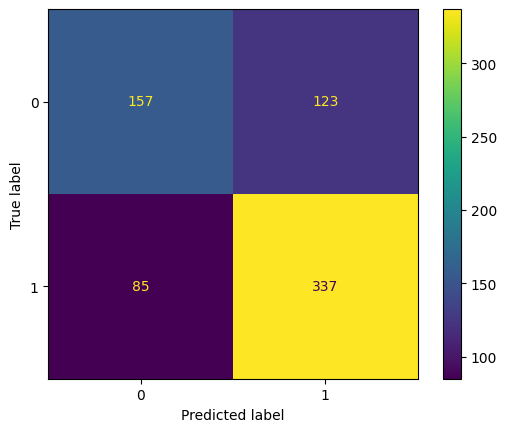

In [41]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

print('AUC: {:.4f}'.format(roc_auc_score(y_target, y_hat)))
print('Accuracy: {:.4f}'.format(accuracy_score(y_target, y_hat>0.6)))

cm = confusion_matrix(y_target, y_hat>0.6)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot() 
plt.show()

In [42]:
y_target = data_df['Amyloid status']
x_data = data_df[['AGE','GENDER','EDUCATION', 'ApoE4']]

In [43]:
clf = LogisticRegression(penalty=None, class_weight=None, max_iter=10000, solver='saga')
clf.fit(x_data, y_target)

y_hat = clf.predict(x_data)
y_prob = clf.predict_proba(x_data)

In [44]:
print(clf.coef_, clf.intercept_)

[[ 0.03238559 -0.19568618 -0.13585834  1.69540545]] [-0.43750395]


In [45]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, train_size=0.75)

clf = LogisticRegression(penalty=None, class_weight=None, max_iter=10000, solver='saga' )
clf.fit(x_train, y_train)

y_hat = clf.predict(x_test)
y_prob = clf.predict_proba(x_test)

AUC: 0.7111
Accuracy: 0.7330


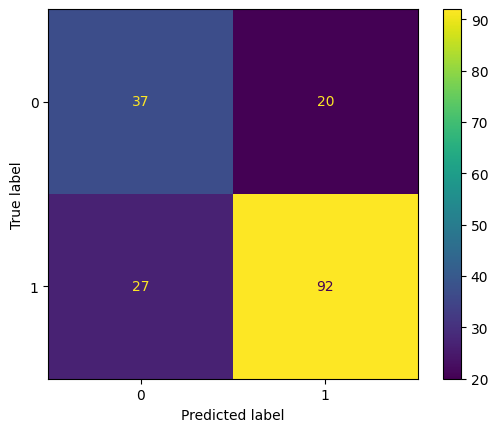

In [46]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

print('AUC: {:.4f}'.format(roc_auc_score(y_test, y_hat)))
print('Accuracy: {:.4f}'.format(accuracy_score(y_test, y_hat>0.6)))

cm = confusion_matrix(y_test, y_hat>0.6)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot() 
plt.show()

In [47]:
kf = KFold(n_splits = 10, shuffle = True)

auc=np.zeros(10)
acc=np.zeros(10)

data_mat = np.array(x_data)
label_mat = np.array(y_target)

for count, (train, test) in enumerate(kf.split(data_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]

  clf = LogisticRegression(penalty=None, class_weight=None, max_iter=10000, solver='saga' )
  clf.fit(train_data, train_label)

  y_hat = clf.predict(test_data)
  y_prob = clf.predict_proba(test_data)

  auc[count] = roc_auc_score(test_label, y_hat)
  acc[count] = accuracy_score(test_label, y_hat>0.6)
  print(count, auc[count], acc[count])


0 0.6995726495726495 0.7323943661971831
1 0.7730434782608696 0.7887323943661971
2 0.7523128679562658 0.7571428571428571
3 0.7555282555282555 0.7571428571428571
4 0.8177777777777778 0.8
5 0.6417157275021026 0.6571428571428571
6 0.6408268733850129 0.6857142857142857
7 0.563063063063063 0.5571428571428572
8 0.6888888888888889 0.7142857142857143
9 0.8061594202898551 0.7714285714285715


In [48]:
print(np.mean(auc), np.mean(acc))

0.7138889002224741 0.722112676056338
